# 03 — Exploratory Data Analysis

**Objetivo:** Entender a distribuição dos dados e identificar os primeiros padrões relevantes para o negócio.

**Análises:**
1. Evolução mensal de pedidos e receita
2. Receita por região
3. Distribuição do valor dos pedidos
4. Horários de pico de entrega
5. Distribuição de idade dos clientes
6. Distribuição de categorias de produtos

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.visualization import bar_chart, line_chart, heatmap

master   = pd.read_parquet("../data/processed/master.parquet")
products = pd.read_parquet("../data/processed/products.parquet")

sns.set_theme(style="whitegrid", palette="Blues_d")
print(f"Dados carregados: {master.shape[0]:,} pedidos")

Dados carregados: 10,000 pedidos


## 1. Evolução mensal de pedidos e receita

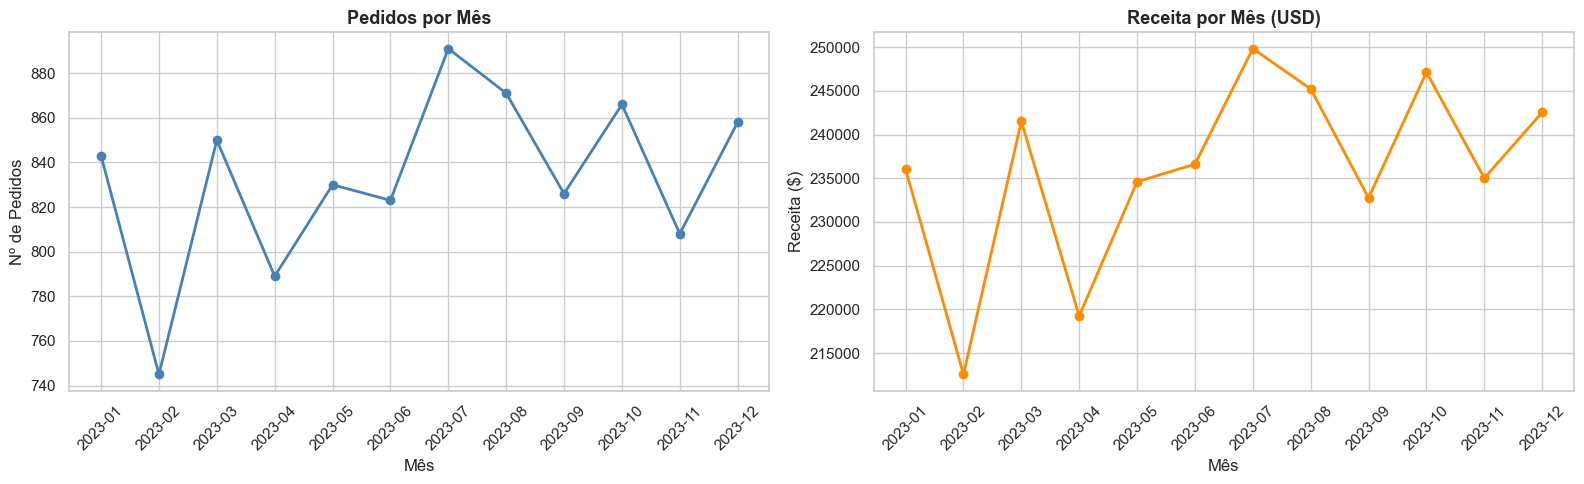

In [2]:
monthly = (
    master.groupby("month")
    .agg(total_orders=("order_id", "count"), total_revenue=("order_amount", "sum"))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(monthly["month"], monthly["total_orders"], marker="o", color="steelblue", linewidth=2)
axes[0].set_title("Pedidos por Mês", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Mês")
axes[0].set_ylabel("Nº de Pedidos")
axes[0].tick_params(axis="x", rotation=45)

axes[1].plot(monthly["month"], monthly["total_revenue"], marker="o", color="darkorange", linewidth=2)
axes[1].set_title("Receita por Mês (USD)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Mês")
axes[1].set_ylabel("Receita ($)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("../reports/figures/01_monthly_trend.png", dpi=150)
plt.show()

## 2. Receita por região

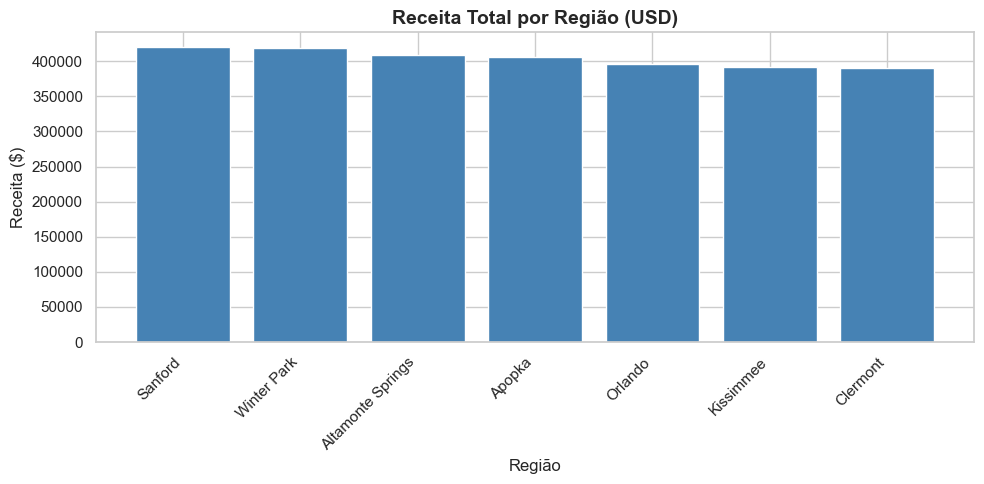

,region,total_revenue
0,Sanford,420210.16
1,Winter Park,419550.38
2,Altamonte Springs,408562.15
3,Apopka,405920.39
4,Orlando,396044.15
5,Kissimmee,392062.58
6,Clermont,390672.57


In [3]:
region_revenue = (
    master.groupby("region")["order_amount"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"order_amount": "total_revenue"})
)

fig = bar_chart(
    region_revenue, x="region", y="total_revenue",
    title="Receita Total por Região (USD)",
    xlabel="Região", ylabel="Receita ($)"
)
fig.savefig("../reports/figures/02_revenue_by_region.png", dpi=150)
plt.show()

display(region_revenue)

## 3. Distribuição do valor dos pedidos

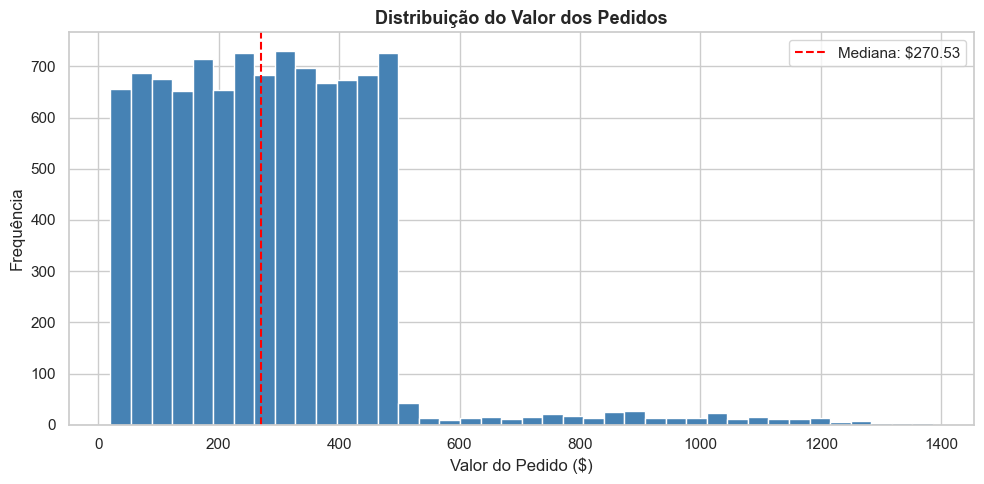

count    $10,000.00
mean        $283.30
std         $181.68
min          $20.08
25%         $147.56
50%         $270.53
75%         $393.07
max       $1,386.00
Name: order_amount, dtype: object


In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(master["order_amount"], bins=40, color="steelblue", edgecolor="white")
ax.axvline(master["order_amount"].median(), color="red", linestyle="--", label=f'Mediana: ${master["order_amount"].median():.2f}')
ax.set_title("Distribuição do Valor dos Pedidos", fontsize=13, fontweight="bold")
ax.set_xlabel("Valor do Pedido ($)")
ax.set_ylabel("Frequência")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/03_order_amount_distribution.png", dpi=150)
plt.show()

print(master["order_amount"].describe().apply(lambda x: f"${x:,.2f}"))

## 4. Heatmap de horários de pico por dia da semana

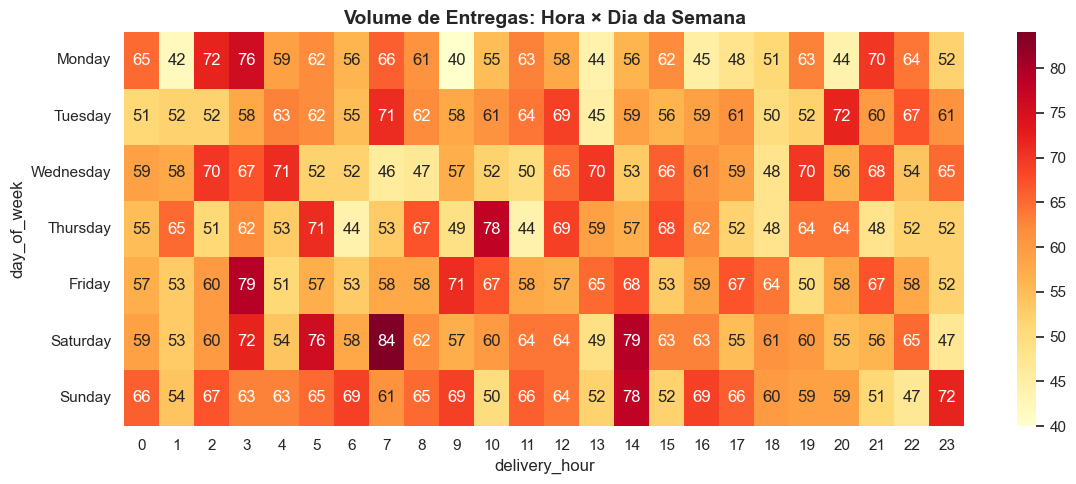

In [5]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

pivot = (
    master.groupby(["day_of_week", "delivery_hour"])["order_id"]
    .count()
    .unstack(fill_value=0)
    .reindex(day_order)
)

fig = heatmap(pivot, title="Volume de Entregas: Hora × Dia da Semana")
fig.savefig("../reports/figures/04_delivery_heatmap.png", dpi=150)
plt.show()

## 5. Distribuição de idade dos clientes

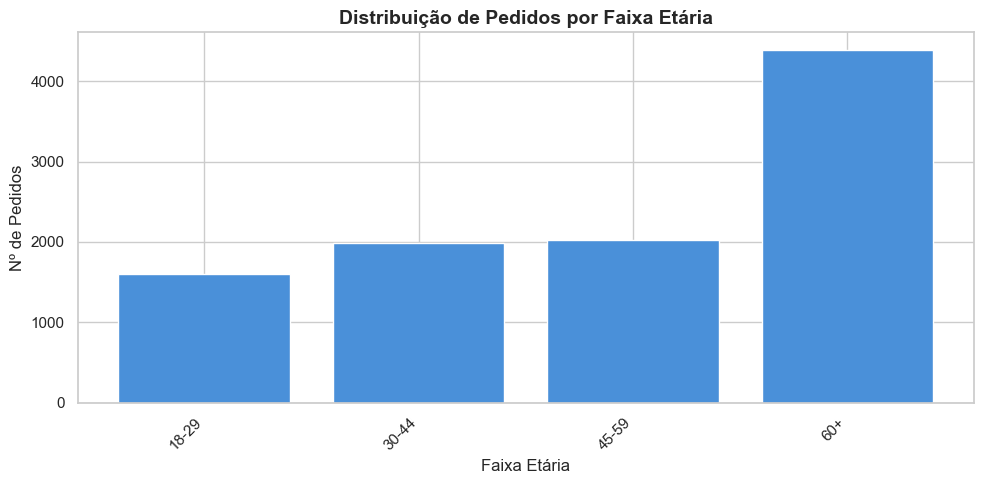

In [6]:
age_bins = [18, 30, 45, 60, 100]
age_labels = ["18-29", "30-44", "45-59", "60+"]

master["age_group"] = pd.cut(master["customer_age"], bins=age_bins, labels=age_labels, right=False)

age_dist = master["age_group"].value_counts().sort_index().reset_index()
age_dist.columns = ["age_group", "count"]

fig = bar_chart(
    age_dist, x="age_group", y="count",
    title="Distribuição de Pedidos por Faixa Etária",
    xlabel="Faixa Etária", ylabel="Nº de Pedidos", color="#4a90d9"
)
fig.savefig("../reports/figures/05_age_distribution.png", dpi=150)
plt.show()

## 6. Categorias de produtos mais pedidos

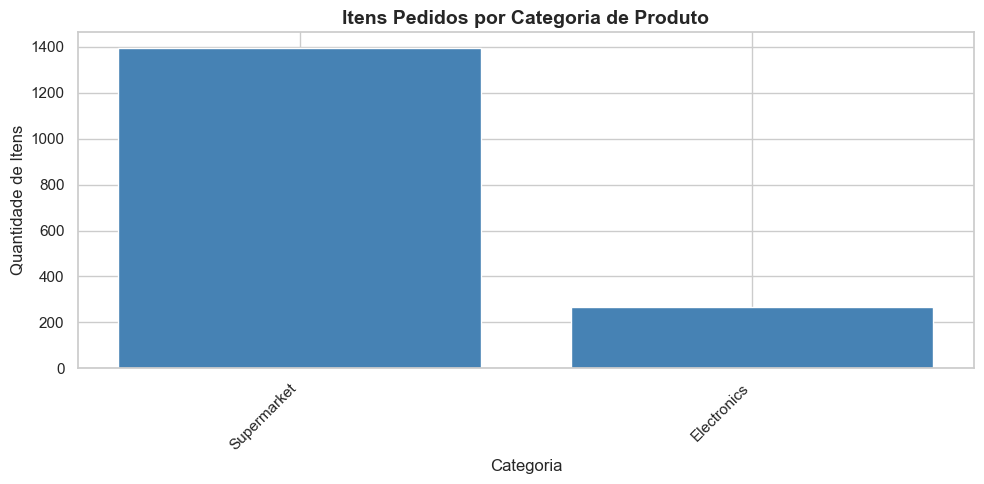

In [7]:
order_items = pd.read_parquet("../data/processed/order_items.parquet")
items_with_cat = order_items.merge(products[["product_id", "category"]], on="product_id", how="left")

cat_counts = (
    items_with_cat["category"]
    .value_counts()
    .reset_index()
)
cat_counts.columns = ["category", "count"]

fig = bar_chart(
    cat_counts, x="category", y="count",
    title="Itens Pedidos por Categoria de Produto",
    xlabel="Categoria", ylabel="Quantidade de Itens"
)
fig.savefig("../reports/figures/06_product_categories.png", dpi=150)
plt.show()